**Week 4 Jupyter Notebook**

**Logistic Regression and Feature Scaling**

**Integrated Capstone Project**: Systemic Banking Risk Assessment

**Objective**

The purpose of this analysis is to apply logistic regression to predict loan default outcomes and evaluate the impact of feature scaling on model performance. Logistic regression is commonly used in banking and finance because it estimates the probability that a borrower will default on a loan.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve
)

In [4]:
# Load Cleaned Dataset

credit_risk = pd.read_csv("credit_risk_cleaned.csv")

credit_risk.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


loan_status
0    25327
1     7089
Name: count, dtype: int64


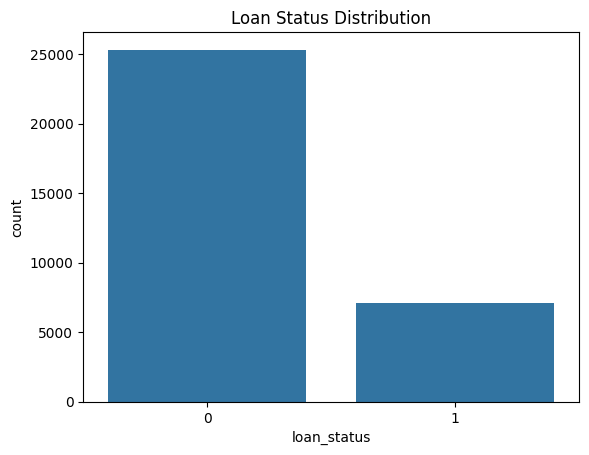

In [5]:
# Explore Target Variable

print(
    credit_risk['loan_status']
    .value_counts()
)

sns.countplot(
    x='loan_status',
    data=credit_risk
)

plt.title(
    'Loan Status Distribution'
)

plt.show()

In [6]:
# Select Features

features = [
    'person_age',
    'person_income',
    'person_emp_length',
    'loan_amnt',
    'loan_int_rate',
    'loan_percent_income',
    'cb_person_cred_hist_length'
]

X = credit_risk[features]

y = credit_risk['loan_status']

In [7]:
# Train-Test Split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [8]:
# Logistic Regression Without Scaling

log_model = LogisticRegression(
    max_iter=1000
)

log_model.fit(
    X_train,
    y_train
)

pred_no_scale = log_model.predict(
    X_test
)

print(
    "Accuracy:",
    accuracy_score(
        y_test,
        pred_no_scale
    )
)

print(
    classification_report(
        y_test,
        pred_no_scale
    )
)

Accuracy: 0.8322023442319556
              precision    recall  f1-score   support

           0       0.85      0.96      0.90      5066
           1       0.71      0.39      0.50      1418

    accuracy                           0.83      6484
   macro avg       0.78      0.67      0.70      6484
weighted avg       0.82      0.83      0.81      6484



In [9]:
# Feature Scaling

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(
    X_train
)

X_test_scaled = scaler.transform(
    X_test
)

In [10]:
# Logistic Regression With Scaling

scaled_model = LogisticRegression(
    max_iter=1000
)

scaled_model.fit(
    X_train_scaled,
    y_train
)

pred_scaled = scaled_model.predict(
    X_test_scaled
)

print(
    "Scaled Accuracy:",
    accuracy_score(
        y_test,
        pred_scaled
    )
)

print(
    classification_report(
        y_test,
        pred_scaled
    )
)

Scaled Accuracy: 0.832048118445404
              precision    recall  f1-score   support

           0       0.85      0.95      0.90      5066
           1       0.71      0.40      0.51      1418

    accuracy                           0.83      6484
   macro avg       0.78      0.68      0.70      6484
weighted avg       0.82      0.83      0.81      6484



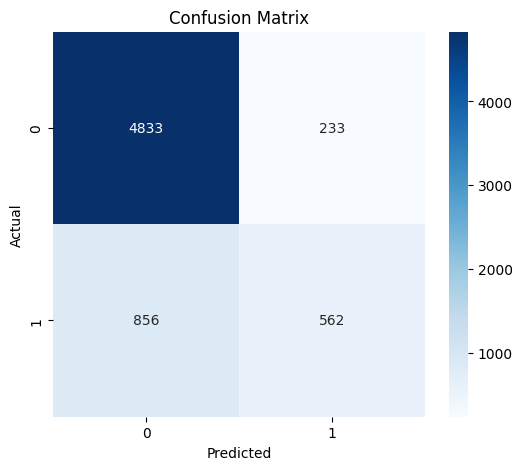

In [11]:
# Confusion Matrix

cm = confusion_matrix(
    y_test,
    pred_scaled
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title(
    'Confusion Matrix'
)

plt.xlabel(
    'Predicted'
)

plt.ylabel(
    'Actual'
)

plt.show()

AUC: 0.8314224730037414


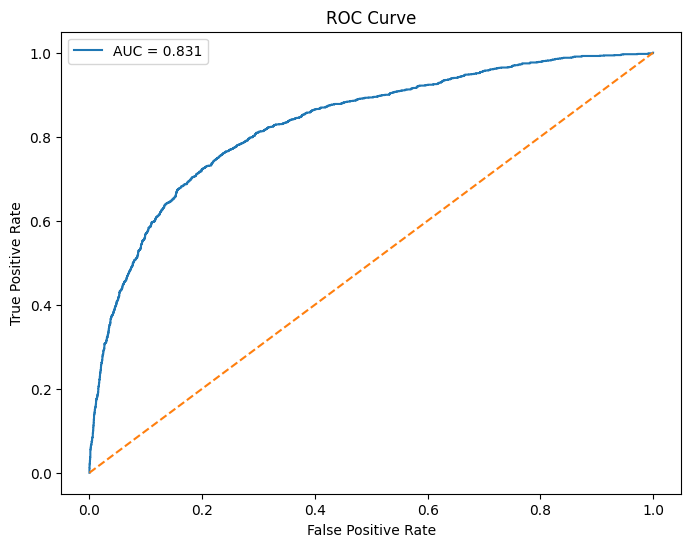

In [12]:
# ROC Curve

probabilities = scaled_model.predict_proba(
    X_test_scaled
)[:,1]

auc_score = roc_auc_score(
    y_test,
    probabilities
)

print(
    "AUC:",
    auc_score
)

fpr, tpr, _ = roc_curve(
    y_test,
    probabilities
)

plt.figure(figsize=(8,6))

plt.plot(
    fpr,
    tpr,
    label=f"AUC = {auc_score:.3f}"
)

plt.plot(
    [0,1],
    [0,1],
    linestyle='--'
)

plt.xlabel(
    "False Positive Rate"
)

plt.ylabel(
    "True Positive Rate"
)

plt.title(
    "ROC Curve"
)

plt.legend()

plt.show()

In [13]:
# Feature Importance

coefficients = pd.DataFrame({
    'Feature':features,
    'Coefficient':
    scaled_model.coef_[0]
})

coefficients = coefficients.sort_values(
    by='Coefficient',
    ascending=False
)

print(coefficients)

                      Feature  Coefficient
5         loan_percent_income     1.242529
4               loan_int_rate     0.944831
0                  person_age     0.045329
1               person_income    -0.004971
6  cb_person_cred_hist_length    -0.030815
2           person_emp_length    -0.106856
3                   loan_amnt    -0.549341


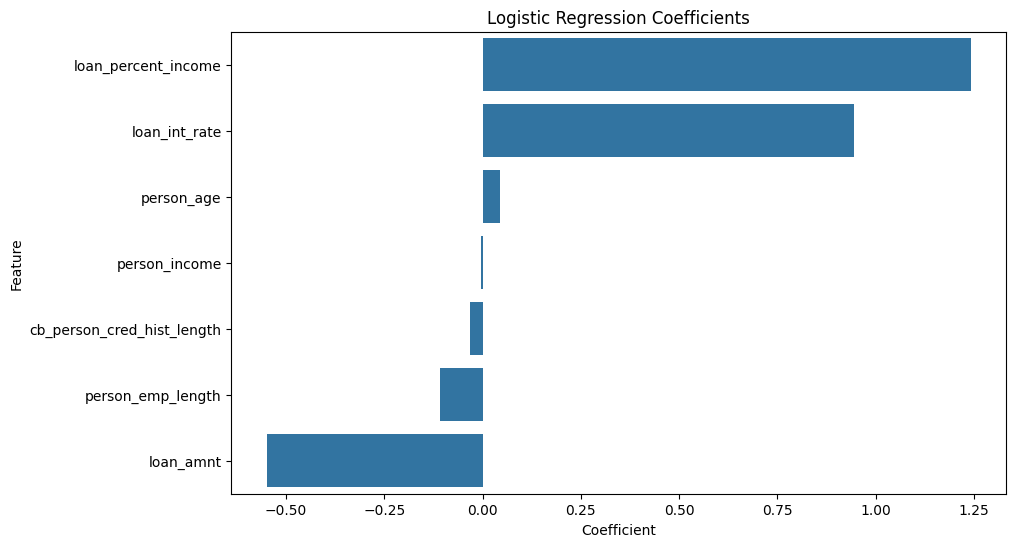

In [14]:
# Visualize Coefficients

plt.figure(figsize=(10,6))

sns.barplot(
    data=coefficients,
    x='Coefficient',
    y='Feature'
)

plt.title(
    'Logistic Regression Coefficients'
)

plt.show()

**Conclusion**

The Week 4 analysis applied logistic regression to predict loan default risk using borrower demographic and financial characteristics. Feature scaling was performed using StandardScaler to ensure that variables measured on different scales contributed appropriately to the model. The coefficient analysis provides insight into which factors are most strongly associated with default risk.

The most influential predictor was loan_percent_income, with a coefficient of 1.243. This positive coefficient indicates that borrowers who devote a larger proportion of their income to loan payments are significantly more likely to default. This finding is consistent with financial risk theory, as higher debt burdens reduce a borrower's ability to absorb unexpected financial shocks.

The second strongest predictor was loan_int_rate, with a coefficient of 0.945. This suggests that borrowers charged higher interest rates are more likely to default. Since lenders often assign higher interest rates to riskier applicants, this result aligns with expectations and indicates that interest rate is an important indicator of credit risk.

Person age had a small positive coefficient (0.045), suggesting a very weak positive relationship with default probability. Compared to the financial variables, age contributes relatively little to predicting default outcomes.

Several variables were associated with lower default risk. Loan amount had a coefficient of −0.549, indicating that larger loans in this dataset were associated with a lower probability of default. This may occur because borrowers who qualify for larger loans often have stronger financial profiles and higher creditworthiness.

Similarly, employment length had a coefficient of −0.107, suggesting that borrowers with longer employment histories are less likely to default. Stable employment generally reflects consistent income and greater financial security.

Credit history length also showed a small negative relationship (−0.031), indicating that borrowers with longer credit histories tend to present lower default risk. Longer credit histories provide lenders with more information regarding repayment behavior and financial responsibility.

Finally, person income had a coefficient very close to zero (−0.005), suggesting that income alone contributes relatively little to default prediction after accounting for other factors such as loan burden and interest rate. This result implies that how much debt a borrower carries relative to income is more important than income level itself.